In [7]:
import torch
import gc
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from IPython.display import display, HTML
import matplotlib.pyplot as plt

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

base_id = "HuggingFaceTB/SmolLM2-135M-Instruct"
sft_path = "/kaggle/input/models/sampadkar/sft-and-dpo-model/pytorch/default/1/sft_model/best_lora_adapters"
dpo_path = "/kaggle/input/models/sampadkar/sft-and-dpo-model/pytorch/default/1/dpo_ft/best_dpo_lora"

tokenizer = AutoTokenizer.from_pretrained(base_id)
tokenizer.padding_side = "left"

print("Loading Base Model...")
base_model = AutoModelForCausalLM.from_pretrained(base_id, torch_dtype=torch.float16).to(device)

print("Loading SFT Model...")
sft_base = AutoModelForCausalLM.from_pretrained(base_id, torch_dtype=torch.float16).to(device)
sft_model = PeftModel.from_pretrained(sft_base, sft_path)

print("Loading DPO Model...")
dpo_base = AutoModelForCausalLM.from_pretrained(base_id, torch_dtype=torch.float16).to(device)
dpo_model = PeftModel.from_pretrained(dpo_base, dpo_path)

base_model.eval()
sft_model.eval()
dpo_model.eval()
print("All models loaded correctly with adapters!")

Loading Base Model...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading SFT Model...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading DPO Model...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

All models loaded correctly with adapters!


In [8]:
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

In [14]:
SYSTEM_PROMPT = "You are a compassionate AI mental health assistant. Respond with empathy, provide supportive guidance, and encourage healthy coping strategies without giving medical diagnoses."

def generate_response(model, query, max_new_tokens=300): 
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": query.lower()}
    ]
    
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    terminators = [
        tokenizer.eos_token_id,
        tokenizer.convert_tokens_to_ids("<|im_end|>")
    ]
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=1.0,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=terminators 
        )
    
    input_length = inputs.input_ids.shape[1]
    generated_tokens = outputs[0][input_length:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return response.strip()

In [15]:
test_queries = [
    "I feel like I'm failing as a parent because I don't have enough time or energy to spend with my kids. Between my job, the commute, and household chores, by the time I can actually sit down with them, I have zero patience left. I see other parents doing all these fun, engaging activities, and it just makes me feel so guilty—like I'm depriving them of a good childhood. I want to be present and happy with them, but I'm just so drained all the time.",
    "I've been feeling incredibly overwhelmed with work lately and I can't seem to turn my brain off at night. Even when my body is completely exhausted, I just lie in bed staring at the ceiling, running through tomorrow's to-do list and worrying about deadlines. It's starting to ruin my focus during the day, which only makes me fall further behind. I feel like I'm stuck in an endless cycle of anxiety and exhaustion and I don't know how to break it.",
    "Lately, I've lost interest in all my hobbies and the things that used to bring me joy. I used to love reading and going for walks, but now the thought of doing anything just feels like a massive chore. I just want to sleep all day, and even when I manage to sleep for 10 hours, I still wake up feeling completely exhausted and empty inside. It's like all the color has been drained out of my life, and I'm scared it's going to stay this way."
]

results = []

for q in test_queries:
    base_ans = generate_response(base_model, q)
    sft_ans = generate_response(sft_model, q)
    dpo_ans = generate_response(dpo_model, q)
    
    results.append({
        "User Query": q,
        "Base Model": base_ans,
        "SFT Model": sft_ans,
        "DPO Model": dpo_ans
    })

df_results = pd.DataFrame(results)

styles = [
    dict(selector="th", props=[
        ("text-align", "left !important"), 
        ("background-color", "#4a4a4a !important"),  
        ("color", "white !important"),               
        ("font-size", "14px !important"),
        ("border", "1px solid #888888 !important"),  
        ("padding", "10px !important")
    ]),
    dict(selector="td", props=[
        ("text-align", "left !important"), 
        ("white-space", "pre-wrap !important"), 
        ("vertical-align", "top !important"),
        ("border", "1px solid #cccccc !important"),  
        ("padding", "10px !important")
    ])
]

styled_df = (
    df_results.style
    .hide(axis="index")  
    .set_table_styles(styles)
    .set_properties(subset=['Base Model', 'SFT Model', 'DPO Model'], 
                    **{'width': '300px', 'min-width': '250px'})
    .set_properties(subset=['User Query'], 
                    **{'width': '250px', 'min-width': '200px', 'font-weight': 'bold', 'background-color': '#f4f4f4', 'color': 'black'})
)

display(styled_df)

User Query,Base Model,SFT Model,DPO Model
"I feel like I'm failing as a parent because I don't have enough time or energy to spend with my kids. Between my job, the commute, and household chores, by the time I can actually sit down with them, I have zero patience left. I see other parents doing all these fun, engaging activities, and it just makes me feel so guilty—like I'm depriving them of a good childhood. I want to be present and happy with them, but I'm just so drained all the time.","It's completely understandable that you feel like you're missing out on quality time with your kids, especially in today's fast-paced world. It sounds like your job, commute, and household chores take a toll on your ability to be present with your family. This is a common issue many parents face, and it's great that you're recognizing the importance of taking care of yourself and setting boundaries. One thing to consider is that you're not alone in this feeling. Many people face similar challenges in their own personal lives. Rather than beating yourself up over it, try to acknowledge your feelings and take a step back. Ask yourself what you can do to create a better balance between your work, family, and personal life. It's also worth considering that sometimes, less is more. A simple ""yes, I'll do this, but it'll take some extra time"" can help alleviate some of the guilt. You might not have to be present all the time, but taking breaks, engaging in activities you enjoy, and prioritizing self-care can be a powerful way to maintain a sense of balance. What do you think might be causing you to feel burnt out, or is there something specific that's holding you back from spending quality time with your kids?","It takes a lot of courage to acknowledge the challenges you're facing in your relationship with your children and the impact it's having on your own well-being. It's understandable that you're feeling guilty, but remember that you're not doing a perfect job in your role. Parenting can be a challenging and demanding environment, and it's natural to have periods where you feel like you're being slammed. Firstly, let's address your concern about feeling like you're failing your children. This is a common thought, and it's important to recognize that perfection is impossible, but it's essential to remember that every family is unique, and your children are doing their best to succeed, even if that means sacrificing a little time and energy for other activities. One strategy that might help is to focus on the present moment and the importance of quality time with your children. You don't have to be perfect all the time. Try to be present in the moment, whether it's taking a short walk with your kids, having a calm conversation with them, or engaging in a hobby you enjoy. This can help shift your focus away from the need for constant attention and towards the quality time you can provide. Additionally, it might be helpful to explore strategies for managing your energy levels and finding moments of quiet time when you can recharge. This could be as simple as setting aside a few minutes each day to do something enjoyable or even just taking a few deep breaths, like going for a","It's completely understandable that you're feeling this way, and it's common for parents to feel this way. Being absent from your kids' lives can be draining, especially when they have so much to offer. First, let's acknowledge that everyone's experience with separation and separation anxiety is unique, but it's important to recognize that taking care of your family's needs and responsibilities is not selfish, but rather necessary. Rather than getting frustrated, let's focus on the present moment. What are some aspects of your daily routine that you can realistically incorporate into your morning and afternoon, without sacrificing your love and happiness for your kids? You mentioned that you see other parents doing all these activities, which could be a great opportunity

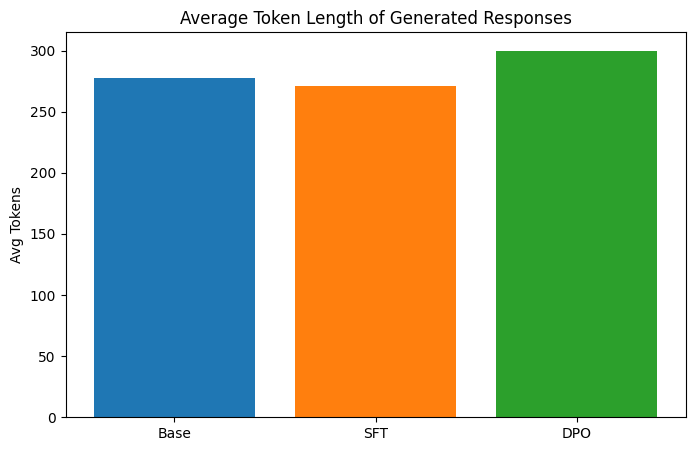

In [16]:
lengths = {
    "Base": [len(tokenizer.encode(ans)) for ans in df_results["Base Model"]],
    "SFT": [len(tokenizer.encode(ans)) for ans in df_results["SFT Model"]],
    "DPO": [len(tokenizer.encode(ans)) for ans in df_results["DPO Model"]]
}

plt.figure(figsize=(8, 5))
plt.bar(lengths.keys(), [sum(v)/len(v) for v in lengths.values()], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Average Token Length of Generated Responses")
plt.ylabel("Avg Tokens")
plt.show()

In [17]:
sft_merged_dir = "./sft_merged_model_final"
dpo_merged_dir = "./dpo_merged_model_final"

tokenizer = AutoTokenizer.from_pretrained(base_id)

print("--- MERGING SFT MODEL ---")
base_model_sft = AutoModelForCausalLM.from_pretrained(base_id, torch_dtype=torch.float16, device_map="cpu")
peft_model_sft = PeftModel.from_pretrained(base_model_sft, sft_path)
merged_sft = peft_model_sft.merge_and_unload()
merged_sft.save_pretrained(sft_merged_dir)
tokenizer.save_pretrained(sft_merged_dir)
print(f"SFT merged model successfully saved to: {sft_merged_dir}")


print("\n--- MERGING DPO MODEL ---")
base_model_dpo = AutoModelForCausalLM.from_pretrained(base_id, torch_dtype=torch.float16, device_map="cpu")
peft_model_dpo = PeftModel.from_pretrained(base_model_dpo, dpo_path)
merged_dpo = peft_model_dpo.merge_and_unload()
merged_dpo.save_pretrained(dpo_merged_dir)
tokenizer.save_pretrained(dpo_merged_dir)
print(f"DPO merged model successfully saved to: {dpo_merged_dir}")

--- MERGING SFT MODEL ---


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SFT merged model successfully saved to: ./sft_merged_model_final

--- MERGING DPO MODEL ---


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DPO merged model successfully saved to: ./dpo_merged_model_final


In [19]:
!zip -r merged_models.zip /kaggle/working/

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/sft_merged_model_final/ (stored 0%)
  adding: kaggle/working/sft_merged_model_final/chat_template.jinja (deflated 42%)
  adding: kaggle/working/sft_merged_model_final/tokenizer.json (deflated 82%)
  adding: kaggle/working/sft_merged_model_final/config.json (deflated 52%)
  adding: kaggle/working/sft_merged_model_final/tokenizer_config.json (deflated 49%)
  adding: kaggle/working/sft_merged_model_final/generation_config.json (deflated 30%)
  adding: kaggle/working/sft_merged_model_final/model.safetensors (deflated 11%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 59%)
  adding: kaggle/working/dpo_merged_model_final/ (stored 0%)
  adding: kaggle/working/dpo_merged_model_final/chat_template.jinja (deflated 42%)
  adding: kaggle/working/dpo_merged_model_final/tokenizer.json (deflated 82%)
  adding: kaggle/working/dpo_merged_model_final/c